In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import norm

from Functions import *
from MMM_Mediation import MMM_Mediation_main


# Color constants
RR = 202
RG = 0
RB = 32

BR = 5
BG = 113
BB = 176

G = 247
W = 256

# PARAMETER RECOVERY (4.3.1)

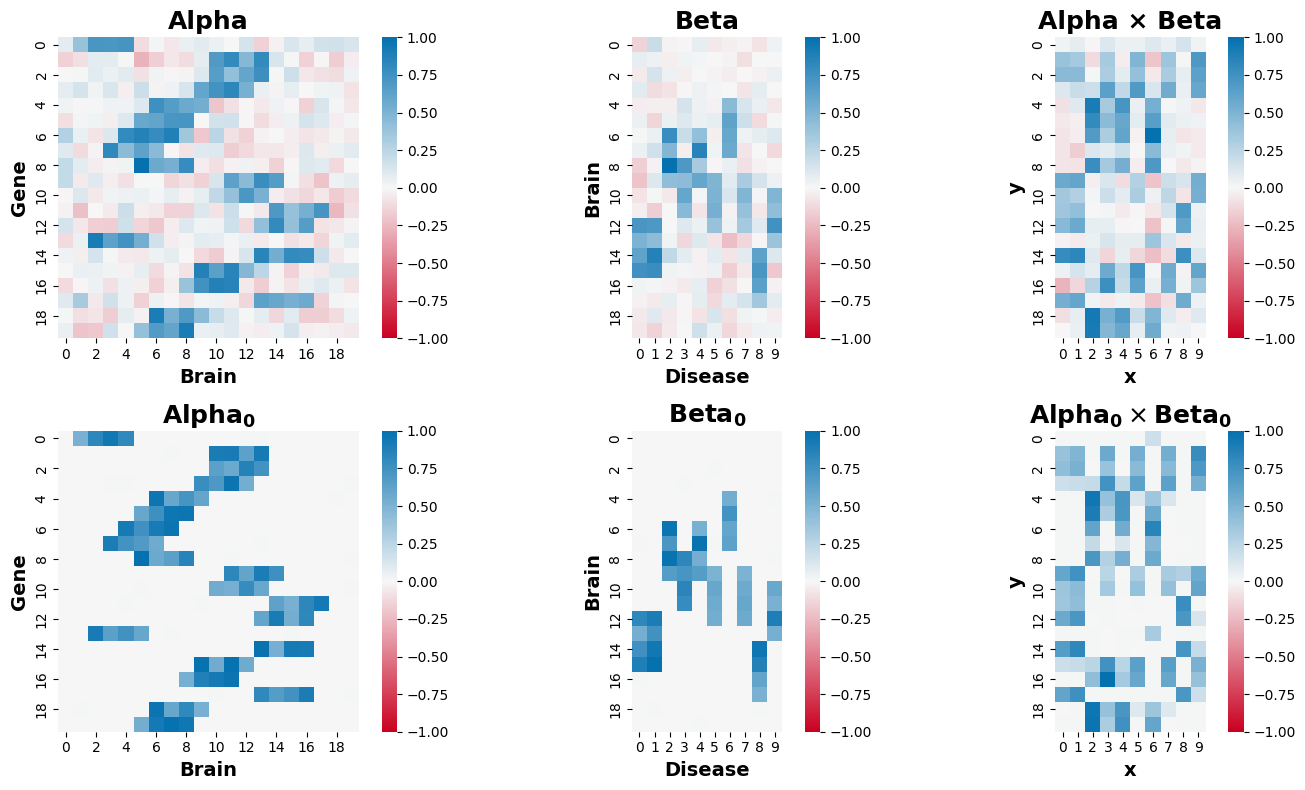

In [18]:
Cov_BG, Brain_BG, Gene_BG, Cog_BG = get_data()
alpha_gen, beta_gen, gamma_gen, zeta_gen, eta_gen, X_gen, Y_gen, M_gen, Z_gen = gen_data()

X = Gene_BG
Y = Cog_BG[:, 1:]
Z = Cov_BG
M = Brain_BG

folds = TTsplit(Cog_BG)

for i in range(Y.shape[0]):
    if Y[i, 0] == "AD":
        Y[i, 0] = 1
    else:
        Y[i, 0] = 0

alpha_gen, beta_gen, gamma_gen, zeta_gen, eta_gen, X_gen, Y_gen, M_gen, Z_gen = gen_data(
    e_noise=100,
    x_noise=100 * 100,
    N=5000,
    iid=True,
)

Opt = MMM_Mediation_main()
Opt.X = X_gen
Opt.Y = Y_gen.T
Opt.Z = Z_gen
Opt.M = M_gen.T

alpha, zeta, beta, gamma, eta, Y_coef = Opt.Training(
    coef_check=True,
    max_iter=5000,
)

matrices1 = [alpha, beta, alpha @ beta]
titles1 = ["Alpha", "Beta", "Alpha × Beta"]

matrices2 = [alpha_gen, beta_gen, alpha_gen @ beta_gen]
titles2 = [
    r"$\mathbf{Alpha_0}$",
    r"$\mathbf{Beta_0}$",
    r"$\mathbf{Alpha_0} \times \mathbf{Beta_0}$",
]

y_labels = ["Gene", "Brain", "y"]
x_labels = ["Brain", "Disease", "x"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

my_cmap = make_double_cmp(
    [RR, G],
    [RG, G],
    [RB, G],
    [BR, G],
    [BG, G],
    [BB, G],
)

for i in range(3):
    ax = axes[0, i]
    sns.heatmap(
        standardize_to_unit(matrices1[i]),
        ax=ax,
        cbar=True,
        square=True,
        cmap=my_cmap,
        vmin=-1,
        vmax=1,
    )
    ax.set_title(titles1[i], fontweight="bold", fontsize=18)
    ax.set_xlabel(x_labels[i], fontweight="bold", fontsize=14)
    ax.set_ylabel(y_labels[i], fontweight="bold", fontsize=14)

for i in range(3):
    ax = axes[1, i]
    sns.heatmap(
        standardize_to_unit(matrices2[i]),
        ax=ax,
        cbar=True,
        square=True,
        cmap=my_cmap,
        vmin=-1,
        vmax=1,
    )
    ax.set_title(titles2[i], fontweight="bold", fontsize=18)
    ax.set_xlabel(x_labels[i], fontweight="bold", fontsize=14)
    ax.set_ylabel(y_labels[i], fontweight="bold", fontsize=14)

plt.tight_layout()
plt.show()

# Stability and false-positive behavior of indirect-effect matrix estimates (4.3.2)

### Stability

In [ ]:
sample_set = [50, 100, 500, 1000, 5000, 10000, 50000, 100000, 200000, 500000]
noise_level = [50, 100, 200, 500, 1000]
seed_lis = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

alphas = []
betas = []
alphas_betas = []
true_alphas = []
true_betas = []

for noise in noise_level:
    alpha_ = []
    beta_ = []
    alpha_beta_ = []

    for N_sample in tqdm(sample_set):
        s_a = []
        s_b = []
        s_ab = []

        for seed in seed_lis:
            (
                alpha_gen,
                beta_gen,
                gamma_gen,
                zeta_gen,
                eta_gen,
                X_gen,
                Y_gen,
                M_gen,
                Z_gen,
            ) = gen_data(
                e_noise=noise,
                x_noise=noise**2,
                N=N_sample,
                seed=seed,
                iid=True,
            )

            Opt = MMM_Mediation_main()
            Opt.X = X_gen
            Opt.Y = Y_gen.T
            Opt.Z = Z_gen
            Opt.M = M_gen.T

            alpha, zeta, beta, gamma, eta, Y_coef = Opt.Training(
                coef_check=True,
                max_iter=5000,
            )

            s_ab.append(alpha @ beta)
            s_a.append(alpha)
            s_b.append(beta)

        alpha_beta_.append(s_ab)
        alpha_.append(s_a)
        beta_.append(s_b)

    alphas.append(alpha_)
    betas.append(beta_)
    alphas_betas.append(alpha_beta_)

    np.save("Results/2b_alpha_beta_b_s_iid", alphas_betas)
    np.save("Results/2b_alpha_b_s_iid", alphas)
    np.save("Results/2b_beta_b_s_iid", betas)

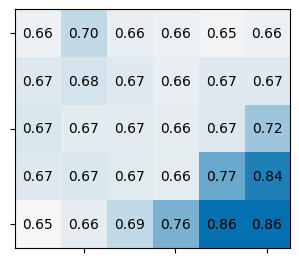

In [4]:
x_labels = [50, 100, 500, 1000, 5000, 10000]
y_labels = [50, 100, 200, 500, 1000]

true_mat = alpha_gen @ beta_gen
pred_tensor = np.load("Results/2b_alpha_beta_b_s_iid.npy")
coverage_mat = np.zeros((5, 6))

for i in range(5):
    for j in range(6):
        pred_ij = pred_tensor[i, j]
        stability, jaccard_mat = mediation_support_stability(
            standard_scaler(pred_ij),
            threshold=0.25,
        )
        coverage_mat[i, j] = stability

fig, ax = plt.subplots(figsize=(3.55, 3.1))

my_cmap = make_cmp([BR, G], [BG, G], [BB, G]).reversed()
im = ax.imshow(
    coverage_mat,
    cmap=my_cmap,
    aspect="auto",
    origin="lower",
)

for i in range(5):
    for j in range(6):
        ax.text(
            j,
            i,
            f"{coverage_mat[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )

plt.xticks(np.arange(len(x_labels)), x_labels)
plt.yticks(np.arange(len(y_labels)), y_labels)

ax.set_xticks([1, 3, 5])
ax.set_xticklabels([])

ax.set_yticks([0, 2, 4])
ax.set_yticklabels([])

ax.tick_params(axis="x", labelsize=9, rotation=45)
ax.tick_params(axis="y", labelsize=9)

### TYPE 1 ERROR

In [ ]:
sample_set = [50, 100, 500, 1000, 5000, 10000, 50000, 100000, 200000, 500000]
noise_level = [50, 100, 200, 500, 1000]
seed_lis = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

true_mat_b = []
true_mat_a = []

for noise in noise_level:
    true_mat_b_ = []
    true_mat_a_ = []

    for N_sample in tqdm(sample_set):
        true_mat_b__ = []
        true_mat_a__ = []

        for seed in seed_lis:
            (
                alpha_gen,
                beta_gen,
                gamma_gen,
                zeta_gen,
                eta_gen,
                X_gen,
                Y_gen,
                M_gen,
                Z_gen,
            ) = gen_data(
                e_noise=noise,
                x_noise=noise**2,
                N=N_sample,
                seed=seed,
                iid=True,
            )

            true_mat_b__.append(beta_gen)
            true_mat_a__.append(alpha_gen)

        true_mat_b_.append(true_mat_b__)
        true_mat_a_.append(true_mat_a__)

    true_mat_b.append(true_mat_b_)
    true_mat_a.append(true_mat_a_)

np.save("Results/2b_beta_true_b.npy", true_mat_b)
np.save("Results/2b_alpha_true_b.npy", true_mat_a)

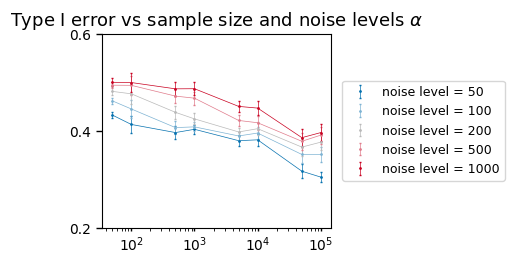

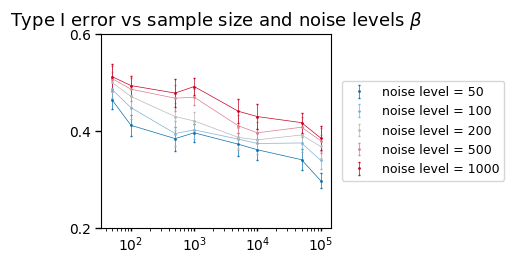

In [5]:
sample_set = [50, 100, 500, 1000, 5000, 10000, 50000, 100000, 200000, 500000]
noise_level = [50, 100, 200, 500, 1000]

top = make_cmp([RR, G], [RG, G], [RB, G], N=3)
bottom = make_cmp([BR, G], [BG, G], [BB, G], N=3)
mid = make_cmp([186, 186], [186, 186], [186, 186], N=1)

new_colors = np.vstack(
    [
        top(np.linspace(0, 1, 3)[:2]),
        mid(np.linspace(0, 1, int(1))),
        bottom(np.linspace(0, 1, 3)[:-1][::-1]),
    ]
)

newcmp = ListedColormap(new_colors)
newcmp = newcmp.reversed()

true_mat_a = np.load("Results/2b_alpha_true_b.npy")
true_mat_b = np.load("Results/2b_beta_true_b.npy")

pred_tensor = np.load("Results/2b_alpha_b_s_iid.npy")

sample_sizes = np.array([50, 100, 500, 1000, 5000, 10000, 50000, 100000])
noise_levels = np.array([50, 100, 200, 500, 1000])

type1_errors = np.zeros((len(noise_levels), len(sample_sizes)))
type1_errors_std = np.zeros((len(noise_levels), len(sample_sizes)))
sem_errors = np.zeros_like(type1_errors)

for i in range(len(noise_levels)):
    for j in range(len(sample_sizes)):
        pred_ij = pred_tensor[i, j]
        true_mat_ij = true_mat_a[i, j]
        r_ij = []

        for t in range(pred_ij.shape[0]):
            r_ij.append(type1_error_rate(true_mat_ij[t], pred_ij[t], alpha=0.1))

        type1_errors[i, j] = np.array(r_ij).mean()
        type1_errors_std[i, j] = np.array(r_ij).std()
        sem_errors[i, j] = type1_errors_std[i, j] / np.sqrt(pred_ij.shape[0])

plt.figure(figsize=(5, 3))

colors = newcmp(np.linspace(0, 1, len(noise_levels)))

for i, nl in enumerate(noise_levels):
    y = type1_errors[i]
    sem = sem_errors[i]

    plt.plot(
        sample_sizes,
        y,
        color=colors[i],
        linewidth=0.5,
    )

    plt.errorbar(
        sample_sizes,
        y,
        yerr=1.96 * sem,
        fmt="o",
        markersize=1,
        color=colors[i],
        ecolor=colors[i],
        elinewidth=0.5,
        capsize=1,
        label=f"noise level = {nl}",
    )

plt.xscale("log")
plt.xlabel("Sample size", fontsize=12)
plt.ylabel("Type I error level", fontsize=12)
plt.title(r"Type I error vs sample size and noise levels $\alpha$", fontsize=13)
plt.legend(title="", fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()

ax = plt.gca()

ax.set_ylim(0.2, 0.6)
ax.set_yticks([0.2, 0.4, 0.6])
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", length=2, width=1.0)
ax.tick_params(axis="y", length=4, width=1.0)

plt.show()

pred_tensor = np.load("Results/2b_beta_b_s_iid.npy")

for i in range(len(noise_levels)):
    for j in range(len(sample_sizes)):
        pred_ij = pred_tensor[i, j]
        true_mat_ij = true_mat_b[i, j]
        r_ij = []

        for t in range(pred_ij.shape[0]):
            r_ij.append(type1_error_rate(true_mat_ij[t], pred_ij[t], alpha=0.1))

        type1_errors[i, j] = np.array(r_ij).mean()
        type1_errors_std[i, j] = np.array(r_ij).std()
        sem_errors[i, j] = type1_errors_std[i, j] / np.sqrt(pred_ij.shape[0])

plt.figure(figsize=(5, 3))

colors = newcmp(np.linspace(0, 1, len(noise_levels)))

for i, nl in enumerate(noise_levels):
    y = type1_errors[i]
    sem = sem_errors[i]

    plt.plot(
        sample_sizes,
        y,
        color=colors[i],
        linewidth=0.5,
    )

    plt.errorbar(
        sample_sizes,
        y,
        yerr=1.96 * sem,
        fmt="o",
        markersize=1,
        color=colors[i],
        ecolor=colors[i],
        elinewidth=0.5,
        capsize=1,
        label=f"noise level = {nl}",
    )

plt.xscale("log")
plt.xlabel("Sample size", fontsize=12)
plt.ylabel("Type I error level", fontsize=12)
plt.title(r"Type I error vs sample size and noise levels $\beta$", fontsize=13)
plt.legend(title="", fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()

ax = plt.gca()

ax.set_ylim(0.2, 0.6)
ax.set_yticks([0.2, 0.4, 0.6])
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", length=2, width=1.0)
ax.tick_params(axis="y", length=4, width=1.0)

plt.show()

# Robustness of the MMM mediation estimator to noise and sample size (4.3.3)

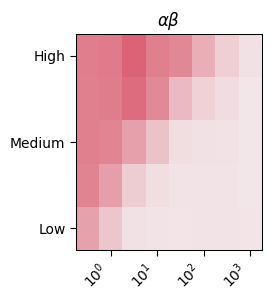

In [6]:
x_labels = [50, 100, 500, 1000, 5000, 10000, 50000, 100000, 200000, 500000]
y_labels = [50, 100, 200, 500, 1000]

my_cmap = make_cmp([RR, G], [RG, G], [RB, G]).reversed()

true_mat_a = np.load("Results/2b_alpha_true_b.npy").mean(axis=2)
true_mat_b = np.load("Results/2b_beta_true_b.npy").mean(axis=2)
pred_tensor = np.load("Results/2b_alpha_beta_b_s_iid.npy").mean(axis=2)

coverage_mat = np.zeros((5, 8))

for i in range(5):
    for j in range(8):
        true_ij = standardize_to_unit(true_mat_a[i, j] @ true_mat_b[i, j])
        pred_ij = standardize_to_unit(pred_tensor[i, j])
        coverage_mat[i, j] = ((pred_ij - true_ij) ** 2).mean()

fig, ax = plt.subplots(figsize=(2.4, 2.8))

im = ax.imshow(
    coverage_mat,
    cmap=my_cmap,
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=1,
)

ax.set_xticks([1, 3, 5, 7])
ax.set_xticklabels(
    [r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$"],
    rotation=45,
    ha="right",
)

ax.set_yticks([0, 2, 4])
ax.set_yticklabels(["Low", "Medium", "High"])

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)
    spine.set_edgecolor("black")

ax.tick_params(axis="both", length=4)
plt.title(r"$\alpha\beta$")

plt.show()

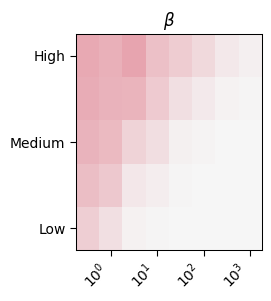

In [7]:
x_labels = [50, 100, 5000, 10000, 50000, 100000, 200000, 500000]
y_labels = [50, 100, 200, 500, 1000]

my_cmap = make_cmp([RR, G], [RG, G], [RB, G]).reversed()

true_mat_b = np.load("Results/2b_beta_true_b.npy").mean(axis=2)
pred_tensor = np.load("Results/2b_beta_b_s_iid.npy").mean(axis=2)

coverage_mat = np.zeros((5, 8))

for i in range(5):
    for j in range(8):
        true_ij = standardize_to_unit(true_mat_b[i, j])
        pred_ij = standardize_to_unit(pred_tensor[i, j])
        coverage_mat[i, j] = ((pred_ij - true_ij) ** 2).mean()

fig, ax = plt.subplots(figsize=(2.4, 2.8))

im = ax.imshow(
    coverage_mat,
    cmap=my_cmap,
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=1,
)

ax.set_xticks([1, 3, 5, 7])
ax.set_xticklabels(
    [r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$"],
    rotation=45,
    ha="right",
)

ax.set_yticks([0, 2, 4])
ax.set_yticklabels(["Low", "Medium", "High"])

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)
    spine.set_edgecolor("black")

ax.tick_params(axis="both", length=4)
plt.title(r"$\beta$")

plt.show()

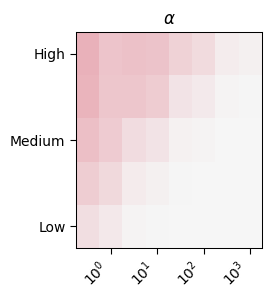

In [8]:
x_labels = [50, 100, 500, 1000, 5000, 10000, 50000, 100000, 200000, 500000]
y_labels = [50, 100, 200, 500, 1000]

my_cmap = make_cmp([RR, G], [RG, G], [RB, G]).reversed()

true_mat_a = np.load("Results/2b_alpha_true_b.npy").mean(axis=2)
pred_tensor = np.load("Results/2b_alpha_b_s_iid.npy").mean(axis=2)
coverage_mat = np.zeros((5, 8))

for i in range(5):
    for j in range(8):
        true_ij = standardize_to_unit(true_mat_a[i, j])
        pred_ij = standardize_to_unit(pred_tensor[i, j])
        coverage_mat[i, j] = ((pred_ij - true_ij) ** 2).mean()

fig, ax = plt.subplots(figsize=(2.4, 2.8))

im = ax.imshow(
    coverage_mat,
    cmap=my_cmap,
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=1,
)

ax.set_xticks([1, 3, 5, 7])
ax.set_xticklabels(
    [r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$"],
    rotation=45,
    ha="right",
)

ax.set_yticks([0, 2, 4])
ax.set_yticklabels(["Low", "Medium", "High"])

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)
    spine.set_edgecolor("black")

ax.tick_params(axis="both", length=4)
plt.title(r"$\alpha$")

plt.show()

# Convergence behavior of the estimators (4.3.4)

### NMRSE vs Correlation

In [ ]:
sample_sizes = [50, 200, 500, 1000, 5000, 10000]

alpha_ = []
beta_ = []
alpha_beta_ = []

for sample in tqdm(sample_sizes):
    Cov_BG, Brain_BG, Gene_BG, Cog_BG = get_data()

    (
        alpha_gen,
        beta_gen,
        gamma_gen,
        zeta_gen,
        eta_gen,
        X_gen,
        Y_gen,
        M_gen,
        Z_gen,
    ) = gen_data(
        e_noise=100,
        x_noise=10000,
        N=sample,
        iid=True,
    )

    X = Gene_BG
    Y = Cog_BG[:, 1:]
    Z = Cov_BG
    M = Brain_BG

    folds = TTsplit(Cog_BG)

    for i in range(Y.shape[0]):
        if Y[i, 0] == "AD":
            Y[i, 0] = 1
        else:
            Y[i, 0] = 0

    Opt = MMM_Mediation_main()
    Opt.X = X_gen
    Opt.Y = Y_gen.T
    Opt.Z = Z_gen
    Opt.M = M_gen.T

    alpha, zeta, beta, gamma, eta, Y_coef = Opt.Training(
        coef_check=True,
        max_iter=5000,
    )

    alpha_.append(alpha)
    beta_.append(beta)
    alpha_beta_.append(alpha @ beta)

    np.save("Results/2d_alpha_iid", alpha_)
    np.save("Results/2d_beta_iid", beta_)
    np.save("Results/2d_alpha_beta_iid", alpha_beta_)

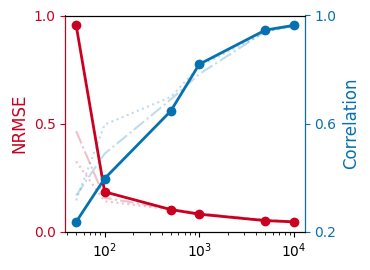

In [9]:
(
    alpha_gen,
    beta_gen,
    gamma_gen,
    zeta_gen,
    eta_gen,
    X_gen,
    Y_gen,
    M_gen,
    Z_gen,
) = gen_data(
    e_noise=100,
    x_noise=10000,
    N=10000,
    iid=True,
)

pred_tensor = np.load("Results/2d_alpha_beta_iid.npy")
true_mat = alpha_gen @ beta_gen

pred_tensor_a = np.load("Results/2d_alpha_iid.npy")
true_mat_a = alpha_gen

pred_tensor_b = np.load("Results/2d_beta_iid.npy")
true_mat_b = beta_gen

sample_sizes = [50, 100, 500, 1000, 5000, 10000]

rmse_values = []
corr_values = []

for k in range(6):
    pred_k = pred_tensor[k]
    rmse_values.append(nrmse(true_mat, pred_k))
    corr_values.append(corr(true_mat, pred_k))

rmse_values = np.array(rmse_values)
corr_values = np.array(corr_values)

rmse_values_a = []
corr_values_a = []

for k in range(6):
    pred_k = pred_tensor_a[k]
    rmse_values_a.append(nrmse(true_mat_a, pred_k))
    corr_values_a.append(corr(true_mat_a, pred_k))

rmse_values_a = np.array(rmse_values_a)
corr_values_a = np.array(corr_values_a)

rmse_values_b = []
corr_values_b = []

for k in range(6):
    pred_k = pred_tensor_b[k]
    rmse_values_b.append(nrmse(true_mat_b, pred_k))
    corr_values_b.append(corr(true_mat_b, pred_k))

rmse_values_b = np.array(rmse_values_b)
corr_values_b = np.array(corr_values_b)

fig, ax1 = plt.subplots(figsize=(3.8, 2.8))

color_rmse = (RR / 255, RG / 255, RB / 255)
color_corr = (BR / 255, BG / 255, BB / 255)

ax1.plot(
    sample_sizes,
    rmse_values,
    linewidth=2,
    color=color_rmse,
    label="RMSE",
    marker="o",
)
ax1.plot(
    sample_sizes,
    rmse_values_a,
    color=color_rmse,
    label="RMSE",
    alpha=0.25,
    linestyle=":",
)
ax1.plot(
    sample_sizes,
    rmse_values_b,
    color=color_rmse,
    label="RMSE",
    alpha=0.25,
    linestyle="-.",
)

ax1.set_xscale("log")
ax1.set_xlabel("")
ax1.set_ylabel("NRMSE", color=color_rmse, fontsize=12)
ax1.tick_params(axis="y", colors=color_rmse, direction="out")
ax1.tick_params(axis="x")

ax2 = ax1.twinx()

ax2.plot(
    sample_sizes,
    corr_values,
    linewidth=2,
    color=color_corr,
    label="Correlation",
    marker="o",
)
ax2.plot(
    sample_sizes,
    corr_values_a,
    color=color_corr,
    label="Correlation",
    alpha=0.25,
    linestyle=":",
)
ax2.plot(
    sample_sizes,
    corr_values_b,
    color=color_corr,
    label="Correlation",
    alpha=0.25,
    linestyle="-.",
)

ax2.set_ylabel("Correlation", color=color_corr, fontsize=12)
ax2.tick_params(axis="y", colors=color_corr, direction="out")

fmt = FuncFormatter(lambda x, _: f"{x:.3f}")
ax1.yaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(fmt)

ymin1, ymax1 = ax1.get_ylim()
ax1.set_yticks(np.linspace(ymin1, ymax1, 3))
ax1.set_yticklabels(["0.0", "0.5", "1.0"])

ymin2, ymax2 = ax2.get_ylim()
ax2.set_yticks(np.linspace(ymin2, ymax2, 3))
ax2.set_yticklabels(["0.2", "0.6", "1.0"])

ax2.spines["left"].set_color(color_rmse)
ax2.spines["right"].set_color(color_corr)

plt.title("")
plt.tight_layout()
plt.show()

### Histogram

In [ ]:
B = 300
N_list = [50, 100, 500, 1000, 5000]

(
    alpha_gen,
    beta_gen,
    gamma_gen,
    zeta_gen,
    eta_gen,
    X_gen,
    Y_gen,
    M_gen,
    Z_gen,
) = gen_data(
    e_noise=100,
    x_noise=10000,
    N=5000,
    seed=10,
    iid=True,
)

beta_2 = []
alpha_2 = []
beta_alpha_2 = []

for N in N_list:
    alpha_lis = np.zeros((B, *alpha_gen.shape))
    beta_lis = np.zeros((B, *beta_gen.shape))
    alpha_beta_lis = np.zeros((B, *(alpha_gen @ beta_gen).shape))

    for b in tqdm(range(B)):
        idx = np.random.choice(N, size=N, replace=True)

        Opt = MMM_Mediation_main()
        Opt.X = X_gen[:, idx]
        Opt.Y = Y_gen.T[:, idx]
        Opt.Z = Z_gen[:, idx]
        Opt.M = M_gen.T[:, idx]

        alpha, zeta, beta, gamma, eta, Y_coef = Opt.Training(
            coef_check=True,
            max_iter=3000,
        )

        alpha_lis[b] = alpha
        beta_lis[b] = beta
        alpha_beta_lis[b] = alpha @ beta

    beta_2.append(beta_lis)
    alpha_2.append(alpha_lis)
    beta_alpha_2.append(alpha_beta_lis)

    np.save("Results/beta_boos_iid", np.array(beta_2))
    np.save("Results/alpha_boos_iid", np.array(alpha_2))
    np.save("Results/alpha_beta_boos_iid", np.array(beta_alpha_2))

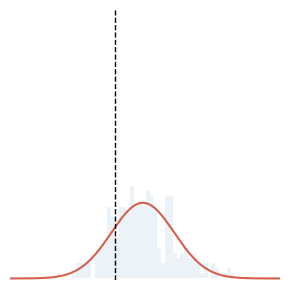

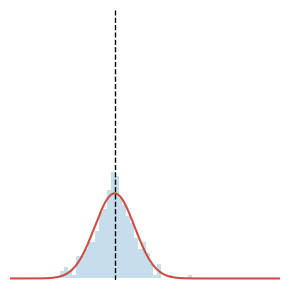

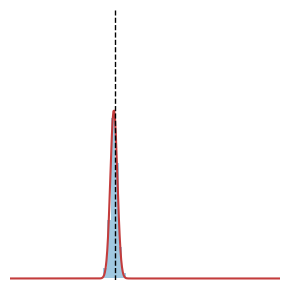

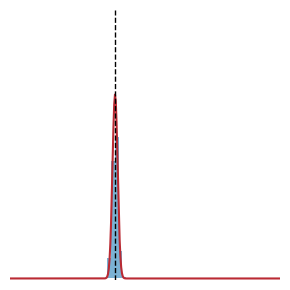

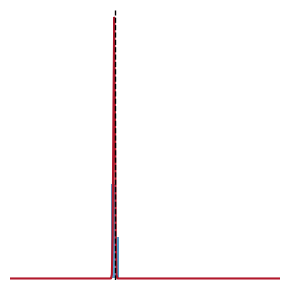

In [12]:
(
    alpha_gen,
    beta_gen,
    gamma_gen,
    zeta_gen,
    eta_gen,
    X_gen,
    Y_gen,
    M_gen,
    Z_gen,
) = gen_data(
    e_noise=100,
    x_noise=10000,
    N=5000,
    seed=10,
    iid=True,
)

sample_sizes = [50, 100, 500, 1000, 5000, 10000]
op = [0.1, 0.3, 0.5, 0.7, 0.9]

boot_pred = np.load("Results/alpha_beta_boos_iid.npy")
true_mat = alpha_gen @ beta_gen

colors = make_cmp(
    [209, 67],
    [229, 147],
    [240, 195],
    N=5,
)(np.linspace(0, 1, 5))

colors_b = make_cmp(
    [178, 214],
    [24, 96],
    [43, 77],
    N=5,
).reversed()(np.linspace(0, 1, 5))

i, j = 14, 7

all_samples = boot_pred[:, :, i, j].reshape(-1)
global_min = all_samples.min()
global_max = all_samples.max()
span = global_max - global_min if global_max > 0 else 1.0

padding = 0.4
x_min = global_min - padding * span
x_max = global_max + padding * span

true_val = true_mat[i, j]

global_ymax = 0.0
lm = []

for k in range(5):
    samples = boot_pred[k, :, i, j]

    hist_vals, bin_edges = np.histogram(
        samples,
        bins=80,
        range=(x_min, x_max),
        density=True,
    )

    mu = samples.mean()
    sigma = samples.std(ddof=1)

    if sigma == 0:
        sigma = 1e-8

    x_grid = np.linspace(x_min, x_max, 400)
    pdf = norm.pdf(x_grid, loc=mu, scale=sigma)

    local_max = max(hist_vals.max(), pdf.max())
    lm.append(local_max)
    global_ymax = max(global_ymax, local_max)

y_shift = 0.01 * global_ymax

for k in range(5):
    samples = boot_pred[k, :, i, j]

    mu = samples.mean()
    sigma = samples.std(ddof=1)

    if sigma == 0:
        sigma = 1e-8

    x_grid = np.linspace(x_min, x_max, 400)
    pdf = norm.pdf(x_grid, loc=mu, scale=sigma)

    plt.figure(figsize=(3, 3))

    plt.hist(
        samples,
        bins=80,
        range=(x_min, x_max),
        density=True,
        color=colors[-1],
        edgecolor="none",
        alpha=op[k],
    )

    plt.plot(
        x_grid,
        pdf,
        color=colors_b[k],
        linewidth=1.5,
    )

    plt.axvline(
        true_val,
        color="black",
        linestyle="--",
        linewidth=1,
    )

    plt.xlim(-5000, 8000)

    a = 0.7
    scale = 1 / (global_ymax / lm[k]) ** (-a)

    plt.ylim(
        -0.00006 / scale,
        global_ymax / scale + 0.0003 / scale,
    )

    ax = plt.gca()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.gcf().patch.set_alpha(0)
    plt.show()

# Assessment of asymptotic normality (4.3.5)

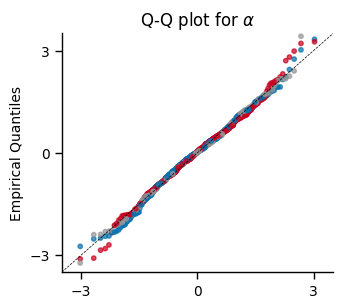

In [13]:
pred_tensor = np.load("Results/2d_alpha_iid.npy")
true_mat = alpha_gen
sample_sizes = [50, 100, 1000]

top = make_cmp([RR, G], [RG, G], [RB, G], N=1)
bottom = make_cmp([BR, G], [BG, G], [BB, G], N=1)
mid = make_cmp([150, 150], [150, 150], [150, 150], N=1)

new_colors = np.vstack(
    [
        top(np.linspace(0, 1, 1)),
        mid(np.linspace(0, 1, 1)),
        bottom(np.linspace(0, 1, 1)),
    ]
)
newcmp = ListedColormap(new_colors)

plt.figure(figsize=(3.5, 3.1))
ax = plt.gca()

colors = newcmp(np.linspace(0, 1, 3))

ox = []
oy = []
cs = []

for idx, N in enumerate(sample_sizes):
    pred = pred_tensor[idx]
    resid = (pred - true_mat).ravel()

    z = (resid - resid.mean()) / resid.std(ddof=1)

    z_sorted = np.sort(z)
    n = len(z_sorted)
    probs = (np.arange(1, n + 1) - 0.5) / n
    q_theory = norm.ppf(probs)

    ox.extend(q_theory)
    oy.extend(z_sorted)
    cs.extend([colors[idx]] * len(q_theory))

ox = np.array(ox)
oy = np.array(oy)
cs = np.array(cs)

perm = np.random.permutation(len(ox))

ox = ox[perm]
oy = oy[perm]
cs = cs[perm]

ax.scatter(ox, oy, color=cs, s=10, alpha=0.7)

lim = 3.5
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)

ax.set_xticks([-3, 0, 3])
ax.set_yticks([-3, 0, 3])

ax.tick_params(axis="both", length=5, width=1.0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.spines["left"].set_edgecolor("black")
ax.spines["bottom"].set_edgecolor("black")

plt.title(r"Q-Q plot for $\alpha$")
plt.xlabel("")
plt.ylabel("Empirical Quantiles")

plt.show()

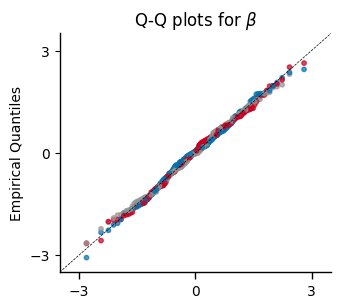

In [14]:
pred_tensor = np.load("Results/2d_beta_iid.npy")
true_mat = beta_gen
sample_sizes = [50, 100, 1000]

top = make_cmp([RR, G], [RG, G], [RB, G], N=1)
bottom = make_cmp([BR, G], [BG, G], [BB, G], N=1)
mid = make_cmp([150, 150], [150, 150], [150, 150], N=1)

new_colors = np.vstack(
    [
        top(np.linspace(0, 1, 1)),
        mid(np.linspace(0, 1, 1)),
        bottom(np.linspace(0, 1, 1)),
    ]
)
newcmp = ListedColormap(new_colors)

plt.figure(figsize=(3.5, 3.1))
ax = plt.gca()

colors = newcmp(np.linspace(0, 1, 3))

ox = []
oy = []
cs = []

for idx, N in enumerate(sample_sizes):
    pred = pred_tensor[idx]
    resid = (pred - true_mat).ravel()

    z = (resid - resid.mean()) / resid.std(ddof=1)

    z_sorted = np.sort(z)
    n = len(z_sorted)
    probs = (np.arange(1, n + 1) - 0.5) / n
    q_theory = norm.ppf(probs)

    ox.extend(q_theory)
    oy.extend(z_sorted)
    cs.extend([colors[idx]] * len(q_theory))

ox = np.array(ox)
oy = np.array(oy)
cs = np.array(cs)

perm = np.random.permutation(len(ox))

ox = ox[perm]
oy = oy[perm]
cs = cs[perm]

ax.scatter(ox, oy, color=cs, s=10, alpha=0.7)

lim = 3.5
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)

ax.set_xticks([-3, 0, 3])
ax.set_yticks([-3, 0, 3])

ax.tick_params(axis="x", length=5, width=1.0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.spines["left"].set_edgecolor("black")
ax.spines["bottom"].set_edgecolor("black")

plt.title(r"Q-Q plots for $\beta$")
plt.xlabel("")
plt.ylabel("Empirical Quantiles")

plt.show()